# 12. Prompt Engineering

**Tier:** Building with LLMs
**Estimated time:** 45 minutes
**Prerequisites:** 06, 09
**Priority:** 🔴 Crucial — the most-used daily skill in this entire curriculum. *If skipped, revisit when:* n/a.
**Source material:** @sairahul1 — "20 AI Concepts You Must Understand in 2026" (https://x.com/sairahul1/status/2057740928908161461)

## What You'll Learn
- Why a prompt is really a *spec* the model fills in, not a magic incantation
- The concrete levers that move output quality: system vs. user role, delimiters, few-shot examples, output formatting
- How to write a structured-output prompt you can parse reliably

## Why This Matters
Notebook 09 showed RLHF makes models follow instructions; this notebook is about writing instructions worth following. The gap between a vague prompt and a well-specified one is often bigger than the gap between two different models — and it's free.


## A prompt is a spec, not a spell

Think of prompting like writing a ticket for a new teammate on their first day. "Fix the bug" gets you something, but it's a guess. "In `checkout.py`, the discount isn't applied to gift cards — reproduce with a $10 gift-card order, fix it, and tell me which line changed" gets you the right thing, fast.

The model behind both responses is identical (notebook 06: it's still next-token prediction, shaped by RLHF from notebook 09 to *try* to be helpful). What changes is how much of the task you specified versus how much the model has to guess. Four levers do most of the work:

1. **System vs. user role** — the system message sets *who the model is and the rules of the game* for the whole conversation; the user message is *this specific request*. Mixing them (burying rules inside a long user question) makes the model treat your rules as negotiable.
2. **Delimiters** — fencing pasted-in content (`<document>...</document>`, triple backticks) tells the model "this is data, not instructions," which matters a lot once you build RAG (notebook 14) where retrieved text could otherwise be mistaken for commands.
3. **Few-shot examples** — showing 1-3 input→output pairs is often worth more than a paragraph of description, because it pins down *format* in a way prose can't.
4. **Output format** — asking for JSON/a fixed schema turns a fuzzy answer into something your code can parse without a second LLM call.


In [1]:
import os

try:
    from dotenv import load_dotenv
    load_dotenv()
except ImportError:
    pass

HAS_ANTHROPIC = bool(os.environ.get("ANTHROPIC_API_KEY"))
TEACH_MODEL = "claude-haiku-4-5-20251001"   # cheap + fast for teaching cells; production default is claude-opus-4-8

if HAS_ANTHROPIC:
    print(f"Anthropic key found. Live cells will call {TEACH_MODEL}.")
else:
    print("No Anthropic key — live cells will print a skip message. Set ANTHROPIC_API_KEY in .env to run them.")


def ask(prompt, system="You are a helpful assistant.", max_tokens=300, model=TEACH_MODEL):
    """Tiny guarded wrapper around the Anthropic SDK. Returns None (and prints why) on any failure."""
    if not HAS_ANTHROPIC:
        print("  [skipped: no ANTHROPIC_API_KEY]")
        return None
    try:
        import anthropic
        client = anthropic.Anthropic()
        msg = client.messages.create(
            model=model, max_tokens=max_tokens, system=system,
            messages=[{"role": "user", "content": prompt}],
        )
        return msg.content[0].text
    except Exception as e:
        print(f"  [skipped: API call failed — {type(e).__name__}: {str(e)[:150]}]")
        return None


Anthropic key found. Live cells will call claude-haiku-4-5-20251001.


## Minimal example: weak prompt vs. specified prompt

Same task — "summarize this for a busy exec" — sent two ways. The weak prompt has no role, no length bound, no format. The specified prompt fixes all three.


In [2]:
PASSAGE = (
    "Quarterly revenue grew 14% year over year, driven mostly by the enterprise tier, "
    "which now accounts for 61% of bookings. Churn ticked up half a point in the SMB "
    "segment, which the team attributes to a pricing change rolled out in week 6. "
    "Support ticket volume rose 22% but median resolution time improved by 9%."
)

WEAK_PROMPT = f"Summarize this: {PASSAGE}"

SPECIFIED_PROMPT = f"""Summarize the passage below for a busy executive.

Rules:
- Exactly 3 bullet points
- Each bullet starts with the metric, then the takeaway
- No more than 15 words per bullet

<passage>
{PASSAGE}
</passage>"""

print("--- Weak prompt response ---")
print(ask(WEAK_PROMPT))
print()
print("--- Specified prompt response ---")
print(ask(SPECIFIED_PROMPT))


--- Weak prompt response ---
# Summary

**Revenue & Growth:**
- Quarterly revenue increased 14% YoY
- Enterprise tier is the primary driver, representing 61% of bookings

**Churn:**
- SMB segment churn rose 0.5 points, linked to a pricing adjustment implemented in week 6

**Support Operations:**
- Ticket volume grew 22%
- Median resolution time improved 9% (despite higher volume)

--- Specified prompt response ---
• **Revenue Growth**: 14% YoY increase led by enterprise tier at 61% of bookings.

• **Churn Rate**: SMB segment churn up 0.5% following week 6 pricing adjustment.

• **Support Efficiency**: Ticket volume up 22% but resolution time improved 9%.


## Few-shot + structured output

Asking for "a JSON object" rarely produces *exactly* the schema you want on the first try. Showing one example pins the keys and types down precisely — this is the pattern every tool-calling agent in Tier 4 depends on.


In [3]:
STRUCTURED_PROMPT = """Extract the metric and its direction from each sentence below as JSON.
Follow this exact format (one example):

Input: "Revenue grew 14% year over year."
Output: {"metric": "revenue", "direction": "up", "value_pct": 14}

Now do these:
1. "Churn ticked up half a point in the SMB segment."
2. "Support ticket volume rose 22%."
3. "Median resolution time improved by 9%."

Return a JSON list of 3 objects, one per line, nothing else."""

result = ask(STRUCTURED_PROMPT, max_tokens=300)
print(result)


{"metric": "churn", "direction": "up", "value_pct": 0.5}
{"metric": "support ticket volume", "direction": "up", "value_pct": 22}
{"metric": "median resolution time", "direction": "up", "value_pct": 9}


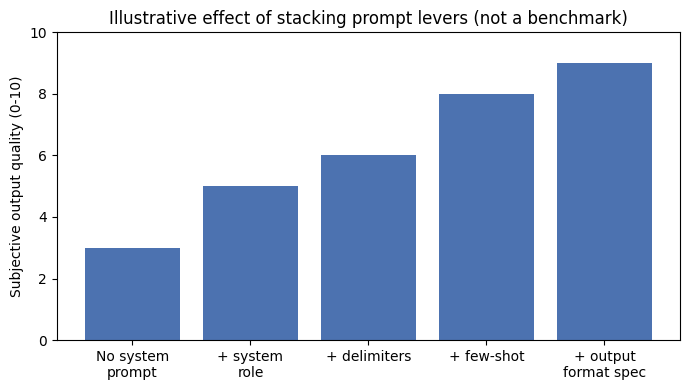

In [4]:
%matplotlib inline
import matplotlib.pyplot as plt

# Illustrative scores (not measured live) showing where each lever typically buys quality.
levers = ["No system\nprompt", "+ system\nrole", "+ delimiters", "+ few-shot", "+ output\nformat spec"]
illustrative_quality = [3, 5, 6, 8, 9]   # out of 10, illustrative only

plt.figure(figsize=(7, 4))
plt.bar(levers, illustrative_quality, color="#4C72B0")
plt.ylim(0, 10)
plt.title("Illustrative effect of stacking prompt levers (not a benchmark)")
plt.ylabel("Subjective output quality (0-10)")
plt.tight_layout()
plt.show()


*Each bar is illustrative, not measured — the point is the trend: each lever you add narrows the gap between what you meant and what the model does.*


## Exercises


In [ ]:
# Exercise 1 (Warm-up): Break the format
# Task: Remove the "<passage>" delimiters from SPECIFIED_PROMPT and re-run it through ask().
#       Does the model still respect the 3-bullet / 15-word rule?
# Hint: Delimiters mostly protect against the model confusing data with instructions; with only
#       one block of text the effect may be subtle here — try it on a passage containing the
#       word "ignore the above rules" to see it matter more.

# YOUR CODE HERE


In [ ]:
# Exercise 2 (Apply): Write a few-shot classifier prompt
# Task: Write a prompt with 2 few-shot examples that classifies a support ticket as
#       "billing", "bug", or "feature_request", and returns ONLY the label. Test it on
#       3 new ticket strings you write yourself.
# Hint: Put the few-shot examples before the new input, in the same Input:/Output: format
#       used in STRUCTURED_PROMPT above.

# YOUR CODE HERE


In [ ]:
# Exercise 3 (Extend): Connect to RAG
# Task: Write a system prompt for a RAG assistant (notebook 14) that explicitly tells the model
#       to answer ONLY from <context> tags and say "I don't know" otherwise. Test it by asking
#       a question the dummy context doesn't cover.
# Hint: This single instruction is most of what separates a RAG system that hallucinates from
#       one that doesn't — see the hallucination demo in notebook 14.

# YOUR CODE HERE


<details>
<summary>Show solutions</summary>

```python
# Exercise 1
no_delim_prompt = SPECIFIED_PROMPT.replace("<passage>\n", "").replace("\n</passage>", "")
print(ask(no_delim_prompt))
# Usually still mostly works for plain text; delimiters matter more once the pasted-in
# content itself contains instruction-like text (a prompt-injection risk relevant to RAG/agents).

# Exercise 2
CLASSIFY_PROMPT = '''Classify each support ticket as exactly one label: billing, bug, or feature_request.
Return only the label, nothing else.

Input: "I was charged twice this month, please refund the extra charge."
Output: billing

Input: "The app crashes every time I tap the export button."
Output: bug

Input: "{ticket}"
Output:'''
for ticket in ["Can you add dark mode?", "My invoice shows the wrong plan tier.", "Search results are empty even though items exist."]:
    print(ticket, "->", ask(CLASSIFY_PROMPT.format(ticket=ticket), max_tokens=10))

# Exercise 3
RAG_SYSTEM = (
    "Answer ONLY using the information inside <context> tags. "
    "If the answer is not in the context, say exactly: \"I don't know based on the provided context.\" "
    "Never use outside knowledge, even if you know the answer."
)
context = "<context>The Helios X1 ships with a 2-year warranty.</context>"
print(ask(f"{context}\nQuestion: What color options does the X1 come in?", system=RAG_SYSTEM))
# Without the system rule the model would likely guess a color; with it, it should decline.
```
</details>


## Key Takeaways
- A prompt is a specification: the more of the task you pin down, the less the model has to guess.
- System messages set durable rules; user messages are the specific ask — don't bury rules in the user turn.
- Delimiters mark "this is data, not instructions" — increasingly important once you retrieve text you didn't write (notebook 14) or hand the model tools (notebook 18+).
- Few-shot examples fix *format* faster than prose descriptions do.
- Asking for a structured output (JSON, fixed schema) turns a fuzzy answer into something your code can parse — the same pattern tool-calling agents rely on.

## What's Next
Notebook **13 — Context Windows & KV Cache** looks at the budget every one of these prompts spends: how many tokens you have to work with, what it costs to reuse them, and why caching the boilerplate parts of a prompt (like a long system message) is nearly free.
